In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np

In [40]:
def plot(ax, filename, maxd, maxp, normalise=True, show_cbar=False):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_param_exploration.no_shot_noise.{filename}.d{maxd}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    deltas = res['delta_bs'] if 'delta_bs' in res.keys() else res['deltas']
    ps = res['ps']
    energies = np.array(energies)
    if normalise:
        # energies /= energies.max()
        energies /= energies[0,0]
    im = ax.pcolormesh(ps, deltas, energies.T, shading='nearest')
    
    if show_cbar:
        cbar = ax.figure.colorbar(im, ax=ax)
        label = '$\\frac{H_C}{\\max(H_C)}$' if normalise else '${H_C}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25)
    ax.set_xlabel('p')
    ax.set_ylabel(r'$\Delta_\beta = \Delta_\gamma$')
    return ax

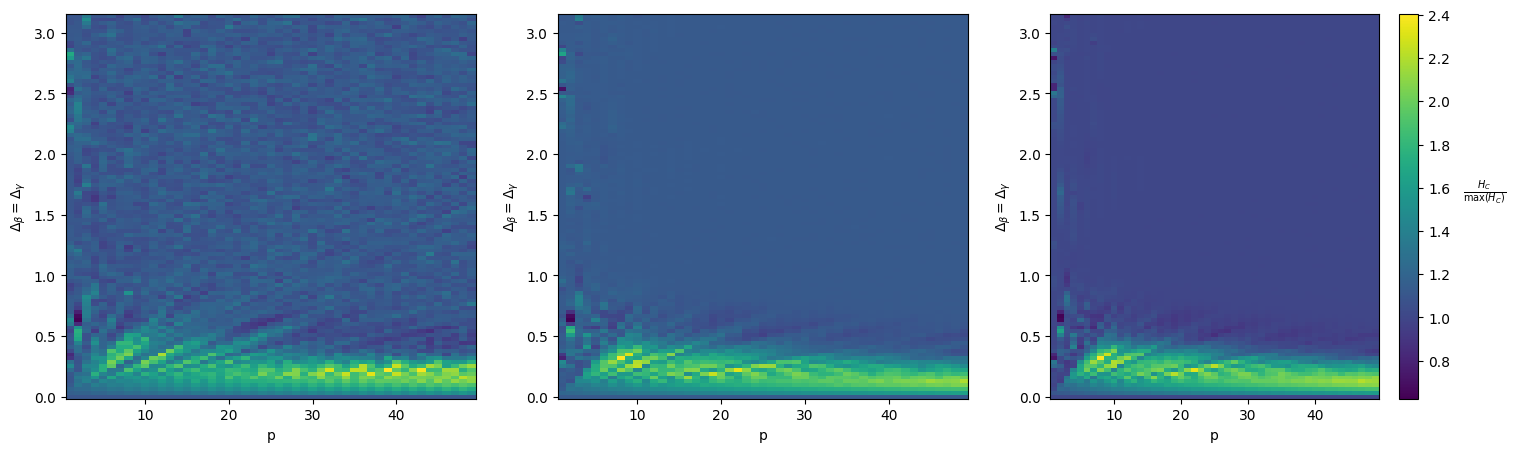

In [41]:
fig, axs = plt.subplots(1, 3)
ax0 = plot(axs[0], 'test_N2_W2', '3.14', '49', True)
ax1 = plot(axs[1],'trivial', '3.14', '49', True)
ax2 = plot(axs[2],'test_N3_W4', '3.14', '49', True, True)
fig.set_figheight(5)
fig.set_figwidth(18)

In [12]:
def plot_3d(axs, filename, maxdb, maxdg, maxp, normalise=True):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_param_exploration.no_shot_noise.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    energies = np.array(energies)
    print(np.min(np.min(energies, axis=1), axis=1))
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]

    norm = colors.Normalize(vmin=np.min(energies), vmax=np.max(energies))

    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))]    
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(delta_bs, delta_gs, energies[plot_ps[i],:,:].T, shading='nearest', norm=norm)
        ax.set_xlabel(r'$\Delta_\beta$')
        ax.set_ylabel(r'$\Delta_\gamma$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$\frac{H_C}{\max(H_C)}$' if normalise else f'$H_C, {np.round(np.min(energies[plot_ps[i],:,:]),2)}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25)
    return axs

[16.20226618  4.89889049 13.27988975]
[30.21122703 11.03512578 27.55056293]
[42.51130475 14.37816636 38.22558285]


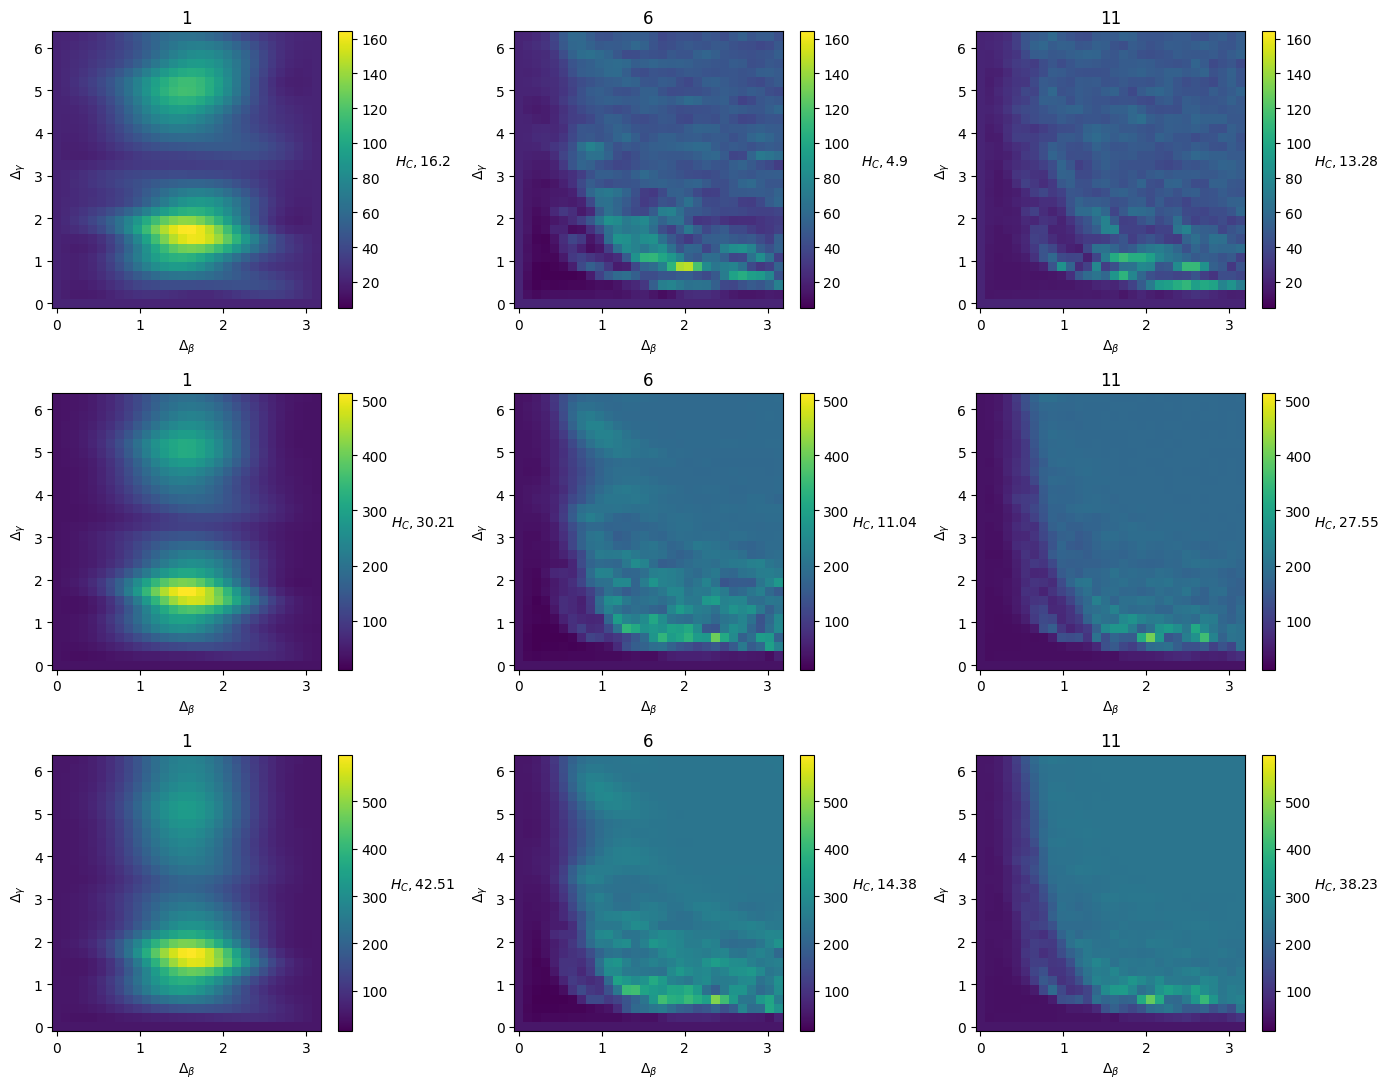

In [13]:
fig, axs = plt.subplots(3, 3)
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs0 = plot_3d(axs0, 'test_N2_W2', '3.13', '6.27', '11', False)
axs0 = plot_3d(axs1, 'trivial', '3.13', '6.27', '11', False)
axs0 = plot_3d(axs2, 'test_N3_W4', '3.13', '6.27', '11', False)
fig.set_figheight(11)
fig.set_figwidth(14)
plt.tight_layout()

[16.11193196  4.63919801 13.26373633]
[30.10863466 10.59974351 27.5382737 ]
[42.41791875 13.94833371 38.07589054]


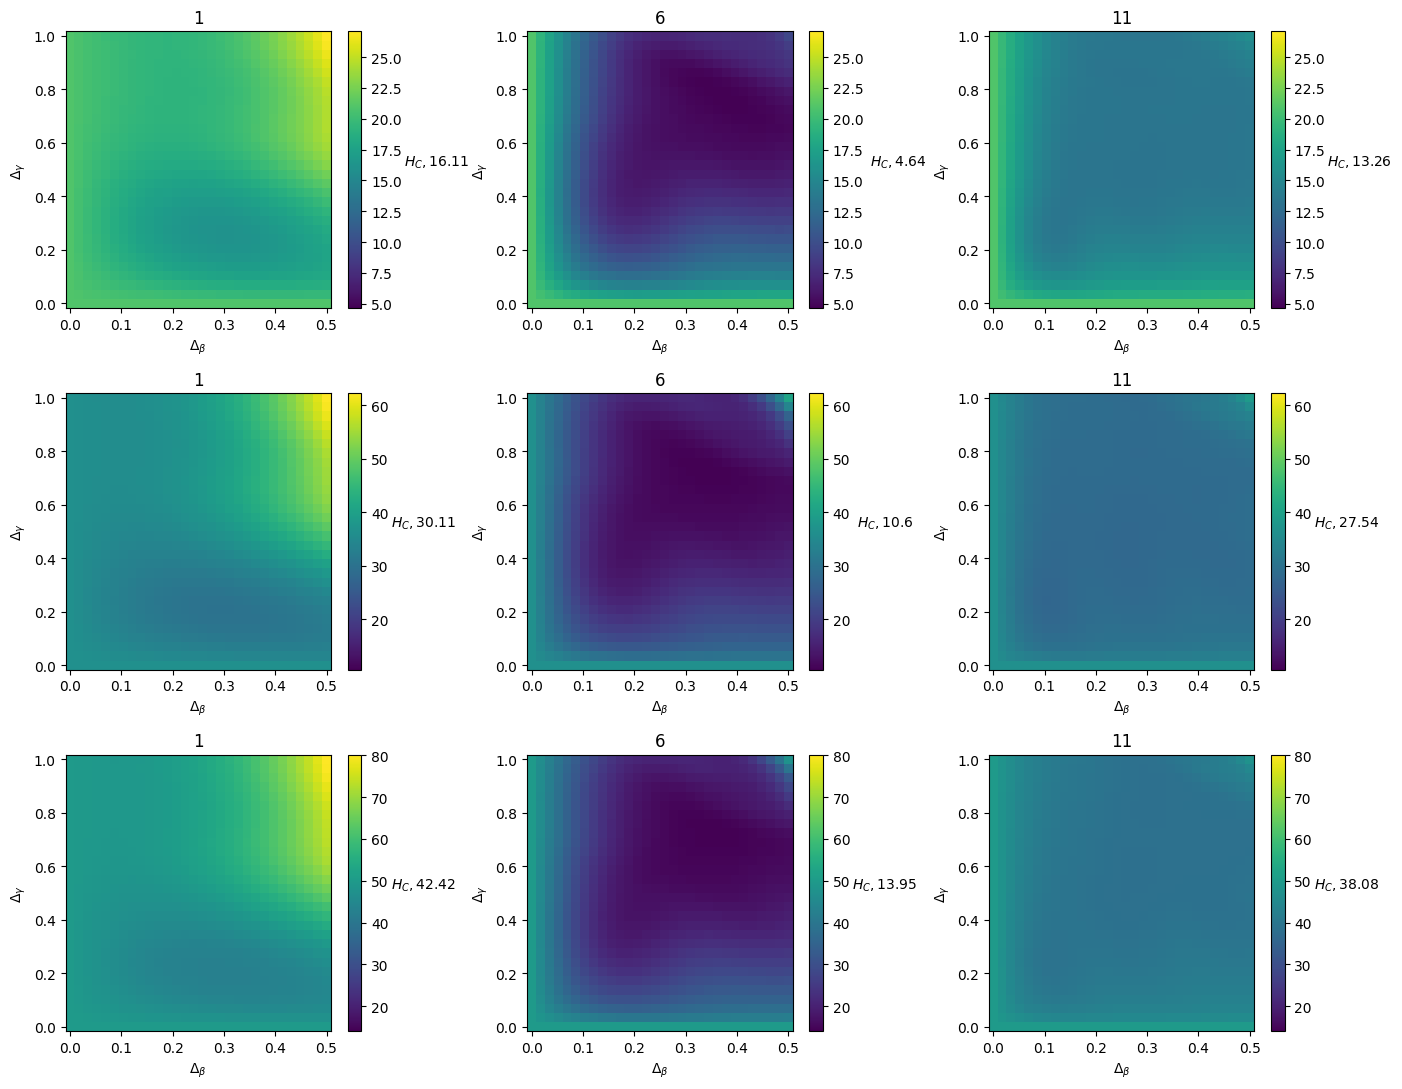

In [17]:
fig, axs = plt.subplots(3, 3)
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs0 = plot_3d(axs0, 'test_N2_W2', '0.5', '1.0', '11', False)
axs0 = plot_3d(axs1, 'trivial', '0.5', '1.0', '11', False)
axs0 = plot_3d(axs2, 'test_N3_W4', '0.5', '1.0', '11', False)
fig.set_figheight(11)
fig.set_figwidth(14)
plt.tight_layout()

In [20]:
# fig, axs = plt.subplots(5, 3)
# axs0 = axs[:, 0]
# axs1 = axs[:, 1]
# axs2 = axs[:, 2]
# axs0 = plot_3d(axs0, 'test_N2_W2', '3.14', '6.28', '29', False)
# axs0 = plot_3d(axs1, 'trivial', '3.14', '49', True)
# axs0 = plot_3d(axs2, 'test_N3_W4', '3.14', '49', True)
# fig.set_figheight(25)
# fig.set_figwidth(18)

In [31]:
with open('/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_param_exploration.no_shot_noise.test_N2_W2.db3.13.dg6.27.p11.pkl', 'rb') as f:
    res = pickle.load(f)

In [32]:
np.min(np.min(res['energies'], axis=1), axis=1)

array([16.20226618,  4.89889049, 13.27988975])

In [30]:
res['ps']

range(1, 30)